In [ ]:
# -*- coding: utf-8 -*-
"""
Пакетный анализ систем детекции отвлечения, наклона и сонливости.

Три независимые системы:
  1. Отвлечение внимания: |yaw| > 30° (поворот головы влево-вправо)
  2. Наклон головы: |roll| > 20° (потеря сознания/засыпание)
  3. Сонливость: EAR < порог (длительное закрытие глаз)

Для каждой системы сравниваются покадровый и политопный подходы.
Метрика — на уровне событий.

Окно политопа: 60 кадров (2 секунды при 30 FPS).

Авторы: Волкова Н.В.
Версия: 1.0 (ВКР)
"""

import warnings
warnings.filterwarnings('ignore')

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from collections import deque
import os
from pathlib import Path
from datetime import datetime
import random

# ============================================================
# ФИКСАЦИЯ СЛУЧАЙНЫХ ФАКТОРОВ
# ============================================================
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print("Библиотеки загружены. Случайные факторы зафиксированы.")

Библиотеки загружены. Случайные факторы зафиксированы.


In [ ]:
class BatchConfig:
    """
    Конфигурация пакетного анализа.
    """

    VIDEO_DIR = Path("test_videos")
    OUTPUT_DIR = Path("batch_distraction_drowsiness")

    POLYTOPE_WINDOW = 60       # 2 секунды при 30 FPS

    K_EAR = 0.6

    # Пороги для извлечения нейтральных кадров для калибровки
    MAR_CLOSED_THRESHOLD = 0.09
    EAR_OPEN_THRESHOLD = 0.20

    # Фиксированные пороги
    YAW_THRESHOLD = 30.0
    ROLL_THRESHOLD = 20.0

    VIDEO_EXTENSIONS = {'.avi', '.mp4', '.mov', '.mkv', '.webm'}

    def __init__(self):
        self.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "plots").mkdir(parents=True, exist_ok=True)
        (self.OUTPUT_DIR / "data").mkdir(parents=True, exist_ok=True)


config = BatchConfig()
print("Конфигурация загружена.")
print(f"  Окно политопа: {config.POLYTOPE_WINDOW} кадров (2 сек)")
print(f"  Порог yaw: ±{config.YAW_THRESHOLD}°")
print(f"  Порог roll: ±{config.ROLL_THRESHOLD}°")

Конфигурация загружена.
  Окно политопа: 60 кадров (2 сек)
  Порог yaw: ±30.0°
  Порог roll: ±20.0°


In [11]:
class FaceMetricsExtractor:
    """Извлечение метрик лица."""

    MAR_TOP_LEFT = 80
    MAR_BOTTOM_LEFT = 82
    MAR_TOP_CENTER = 13
    MAR_BOTTOM_CENTER = 14
    MAR_TOP_RIGHT = 312
    MAR_BOTTOM_RIGHT = 317
    MAR_LEFT_CORNER = 78
    MAR_RIGHT_CORNER = 308

    LEFT_EYE_IDX = [362, 385, 387, 263, 373, 380]
    RIGHT_EYE_IDX = [33, 160, 158, 133, 153, 144]

    NOSE_TIP_IDX = 1
    CHIN_IDX = 152
    LEFT_EYE_OUTER = 33
    RIGHT_EYE_OUTER = 263

    POSE_IDS = [1, 152, 33, 263, 61, 291]
    FACE_3D = np.array([
        [0.0, 0.0, 0.0],
        [0.0, -330.0, -65.0],
        [-225.0, 170.0, -135.0],
        [225.0, 170.0, -135.0],
        [-150.0, -150.0, -125.0],
        [150.0, -150.0, -125.0]
    ], dtype=np.float64)

    def __init__(self):
        self.mp_face_mesh = mp.solutions.face_mesh
        self.face_mesh = None

    def initialize(self):
        self.face_mesh = self.mp_face_mesh.FaceMesh(
            static_image_mode=False,
            max_num_faces=1,
            refine_landmarks=True,
            min_detection_confidence=0.5,
            min_tracking_confidence=0.5
        )

    def release(self):
        if self.face_mesh is not None:
            self.face_mesh.close()

    def compute_mar(self, landmarks, w, h):
        def pt(idx):
            return np.array([landmarks[idx].x * w, landmarks[idx].y * h])
        v_left = np.linalg.norm(pt(self.MAR_TOP_LEFT) - pt(self.MAR_BOTTOM_LEFT))
        v_center = np.linalg.norm(pt(self.MAR_TOP_CENTER) - pt(self.MAR_BOTTOM_CENTER))
        v_right = np.linalg.norm(pt(self.MAR_TOP_RIGHT) - pt(self.MAR_BOTTOM_RIGHT))
        horizontal = np.linalg.norm(pt(self.MAR_LEFT_CORNER) - pt(self.MAR_RIGHT_CORNER))
        if horizontal < 1e-6:
            return 0.0
        return (v_left + v_center + v_right) / (3.0 * horizontal)

    def compute_ear(self, landmarks, eye_idx, w, h):
        pts = np.array([[landmarks[i].x * w, landmarks[i].y * h] for i in eye_idx])
        vertical = (np.linalg.norm(pts[1] - pts[5]) + np.linalg.norm(pts[2] - pts[4]))
        horizontal = 2.0 * np.linalg.norm(pts[0] - pts[3])
        return vertical / (horizontal + 1e-6)

    def get_head_pose(self, landmarks, h, w):
        pts_2d = np.array(
            [(landmarks[i].x * w, landmarks[i].y * h) for i in self.POSE_IDS],
            dtype=np.float64
        )
        focal = float(w)
        cam_mat = np.array([
            [focal, 0.0, float(w) / 2.0],
            [0.0, focal, float(h) / 2.0],
            [0.0, 0.0, 1.0]
        ], dtype=np.float64)
        dist = np.zeros((4, 1), dtype=np.float64)
        ok, rvec, _ = cv2.solvePnP(self.FACE_3D, pts_2d, cam_mat, dist)
        if not ok:
            return None, None, None
        rmat, _ = cv2.Rodrigues(rvec)
        angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
        return angles[1], angles[0], angles[2]

In [12]:
class Polytope1D:
    """Одномерный политоп."""

    def __init__(self, window_size, threshold, mode='above'):
        self.window_size = window_size
        self.threshold = threshold
        self.mode = mode
        self.buffer = deque(maxlen=window_size)

    def add_frame(self, value):
        self.buffer.append(value)

    def is_full(self):
        return len(self.buffer) >= self.window_size

    def check(self):
        if not self.is_full():
            return False
        if self.mode == 'above':
            return min(self.buffer) >= self.threshold
        else:
            return max(self.buffer) < self.threshold

In [13]:
class SingleVideoAnalyzer:
    """Анализ одного видео: отвлечение, наклон, сонливость."""

    def __init__(self, config, extractor):
        self.config = config
        self.extractor = extractor

    def count_events(self, detection_array):
        events = 0
        in_event = False
        for val in detection_array:
            if val and not in_event:
                events += 1
                in_event = True
            elif not val:
                in_event = False
        return events

    def analyze(self, video_path):
        video_name = video_path.stem

        cap = cv2.VideoCapture(str(video_path))
        if not cap.isOpened():
            print(f"  Не удалось открыть: {video_path.name}")
            return None

        actual_fps = cap.get(cv2.CAP_PROP_FPS)
        if actual_fps <= 0:
            actual_fps = 30.0

        self.extractor.initialize()
        all_frames = []
        frame_idx = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res = self.extractor.face_mesh.process(rgb)
            if res.multi_face_landmarks:
                landmarks = res.multi_face_landmarks[0].landmark
                h, w = frame.shape[:2]
                mar = self.extractor.compute_mar(landmarks, w, h)
                ear_l = self.extractor.compute_ear(landmarks, self.extractor.LEFT_EYE_IDX, w, h)
                ear_r = self.extractor.compute_ear(landmarks, self.extractor.RIGHT_EYE_IDX, w, h)
                ear = (ear_l + ear_r) / 2.0
                yaw, pitch, roll = self.extractor.get_head_pose(landmarks, h, w)
                if yaw is not None:
                    all_frames.append({
                        'idx': frame_idx,
                        'time_sec': frame_idx / actual_fps,
                        'mar': mar,
                        'ear': ear,
                        'yaw': yaw,
                        'roll': roll
                    })
            frame_idx += 1

        cap.release()
        self.extractor.release()

        if len(all_frames) < 30:
            print(f"  {video_name}: исключено — мало кадров")
            return None

        df_video = pd.DataFrame(all_frames)

        # Калибровка EAR по нейтральным кадрам
        neutral_mask = (
            (df_video['mar'] < self.config.MAR_CLOSED_THRESHOLD) &
            (df_video['ear'] > self.config.EAR_OPEN_THRESHOLD)
        )
        neutral_frames = df_video[neutral_mask].copy()

        neutral_ratio = len(neutral_frames) / len(df_video)
        if neutral_ratio < 0.10:
            print(f"  {video_name}: исключено — нейтральных кадров "
                  f"{len(neutral_frames)} ({neutral_ratio*100:.1f}%)")
            return None

        ear_baseline = neutral_frames['ear'].median()
        ear_threshold = ear_baseline * self.config.K_EAR

        # Три политопа
        polytope_distraction = Polytope1D(
            window_size=self.config.POLYTOPE_WINDOW,
            threshold=self.config.YAW_THRESHOLD, mode='above'
        )
        polytope_roll = Polytope1D(
            window_size=self.config.POLYTOPE_WINDOW,
            threshold=self.config.ROLL_THRESHOLD, mode='above'
        )
        polytope_drowsiness = Polytope1D(
            window_size=self.config.POLYTOPE_WINDOW,
            threshold=ear_threshold, mode='below'
        )

        n = len(df_video)
        frame_dist = np.zeros(n, dtype=bool)
        poly_dist = np.zeros(n, dtype=bool)
        frame_roll = np.zeros(n, dtype=bool)
        poly_roll = np.zeros(n, dtype=bool)
        frame_drows = np.zeros(n, dtype=bool)
        poly_drows = np.zeros(n, dtype=bool)

        for i, (_, row) in enumerate(df_video.iterrows()):
            yaw_abs = abs(row['yaw'])
            roll_abs = abs(row['roll'])
            ear = row['ear']

            frame_dist[i] = yaw_abs >= self.config.YAW_THRESHOLD
            polytope_distraction.add_frame(yaw_abs)
            poly_dist[i] = polytope_distraction.check()

            frame_roll[i] = roll_abs >= self.config.ROLL_THRESHOLD
            polytope_roll.add_frame(roll_abs)
            poly_roll[i] = polytope_roll.check()

            frame_drows[i] = ear < ear_threshold
            polytope_drowsiness.add_frame(ear)
            poly_drows[i] = polytope_drowsiness.check()

        results = {}
        for key, name, frame_arr, poly_arr in [
            ('distraction', 'Отвлечение', frame_dist, poly_dist),
            ('roll', 'Наклон', frame_roll, poly_roll),
            ('drowsiness', 'Сонливость', frame_drows, poly_drows),
        ]:
            frame_events = self.count_events(frame_arr)
            poly_events = self.count_events(poly_arr)
            reduction = ((frame_events - poly_events) / max(frame_events, 1) * 100)
            results[key] = {
                'name': name,
                'frame_cadrs': int(frame_arr.sum()),
                'poly_cadrs': int(poly_arr.sum()),
                'frame_events': frame_events,
                'poly_events': poly_events,
                'reduction': reduction
            }

        print(f"  Нейтр: {len(neutral_frames)} ({neutral_ratio*100:.1f}%), "
              f"EAR порог: {ear_threshold:.4f}")
        for key in ['distraction', 'roll', 'drowsiness']:
            r = results[key]
            print(f"  {r['name']}: покадр {r['frame_events']}, "
                  f"политоп {r['poly_events']}, сниж {r['reduction']:.1f}%")

        data_path = self.config.OUTPUT_DIR / "data" / f"{video_name}_metrics.csv"
        df_video.to_csv(data_path, index=False)

        return {
            'video_name': video_name,
            'total_frames': len(df_video),
            'neutral_frames': len(neutral_frames),
            'neutral_ratio': neutral_ratio,
            'ear_baseline': ear_baseline,
            'ear_threshold': ear_threshold,
            'distraction_frame_events': results['distraction']['frame_events'],
            'distraction_poly_events': results['distraction']['poly_events'],
            'distraction_reduction': results['distraction']['reduction'],
            'roll_frame_events': results['roll']['frame_events'],
            'roll_poly_events': results['roll']['poly_events'],
            'roll_reduction': results['roll']['reduction'],
            'drowsiness_frame_events': results['drowsiness']['frame_events'],
            'drowsiness_poly_events': results['drowsiness']['poly_events'],
            'drowsiness_reduction': results['drowsiness']['reduction'],
        }

In [14]:
class BatchComparator:
    """Пакетное сравнение."""

    def __init__(self, config, analyzer):
        self.config = config
        self.analyzer = analyzer

    def run(self):
        video_dir = self.config.VIDEO_DIR
        if not video_dir.exists():
            raise FileNotFoundError(f"Папка не найдена: {video_dir}")

        video_paths = []
        for ext in self.config.VIDEO_EXTENSIONS:
            video_paths.extend(video_dir.glob(f"*{ext}"))
            video_paths.extend(video_dir.glob(f"*{ext.upper()}"))
        video_paths = sorted(set(video_paths))

        print(f"Найдено видео: {len(video_paths)}")

        all_results = []
        for i, vp in enumerate(video_paths):
            print(f"\n[{i+1}/{len(video_paths)}] {vp.name}")
            result = self.analyzer.analyze(vp)
            if result:
                all_results.append(result)

        if not all_results:
            return None

        df_results = pd.DataFrame(all_results)
        df_results.to_csv(self.config.OUTPUT_DIR / "batch_results.csv", index=False)
        return df_results

In [15]:
class BatchVisualizer:
    """Визуализация результатов."""

    def __init__(self, config):
        self.config = config
        self.output_dir = config.OUTPUT_DIR / "plots"

    def plot_summary(self, df_results):
        if df_results is None or len(df_results) == 0:
            return

        fig, axes = plt.subplots(3, 1, figsize=(18, 14))
        video_names = df_results['video_name'].values

        systems = [
            ('distraction', 'Отвлечение (|yaw|>30°)', axes[0]),
            ('roll', 'Наклон (|roll|>20°)', axes[1]),
            ('drowsiness', 'Сонливость (EAR<порог)', axes[2]),
        ]

        for key, title, ax in systems:
            x = np.arange(len(video_names))
            width = 0.35
            ax.bar(x - width/2, df_results[f'{key}_frame_events'], width,
                   label='Покадровый', color='lightcoral', edgecolor='black')
            ax.bar(x + width/2, df_results[f'{key}_poly_events'], width,
                   label='Политопный', color='steelblue', edgecolor='black')
            ax.set_xticks(x)
            ax.set_xticklabels(video_names, rotation=45, ha='right', fontsize=7)
            ax.set_ylabel('Событий')
            ax.set_title(title)
            ax.legend(fontsize=7)
            ax.grid(True, alpha=0.3, axis='y')

        plt.suptitle(
            f'Детекция отвлечения, наклона и сонливости\n'
            f'Видео: {len(df_results)}, окно политопа: {config.POLYTOPE_WINDOW} кад (2 сек)',
            fontsize=14
        )
        plt.tight_layout()
        plot_path = self.output_dir / "batch_summary.png"
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"График сохранен: {plot_path}")

In [16]:
class ReportGenerator:
    """Генерация отчета."""

    def __init__(self, config):
        self.config = config

    def generate(self, df_results):
        if df_results is None or len(df_results) == 0:
            return

        lines = []
        lines.append("=" * 60)
        lines.append("ОТЧЕТ: ОТВЛЕЧЕНИЕ, НАКЛОН, СОНЛИВОСТЬ")
        lines.append("=" * 60)
        lines.append(f"Дата: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
        lines.append(f"Видео: {len(df_results)}")
        lines.append(f"Окно политопа: {config.POLYTOPE_WINDOW} кад (2 сек)")
        lines.append("")

        for key, name in [('distraction', 'Отвлечение (|yaw|>30°)'),
                          ('roll', 'Наклон (|roll|>20°)'),
                          ('drowsiness', 'Сонливость (EAR<порог)')]:
            total_frame = df_results[f'{key}_frame_events'].sum()
            total_poly = df_results[f'{key}_poly_events'].sum()
            avg_reduction = df_results[f'{key}_reduction'].mean()
            lines.append(f"{name}:")
            lines.append(f"  Покадровых событий: {total_frame}")
            lines.append(f"  Политопных событий: {total_poly}")
            if total_frame > 0:
                lines.append(f"  Общее снижение: {(total_frame-total_poly)/total_frame*100:.1f}%")
            lines.append(f"  Среднее снижение: {avg_reduction:.1f}%")
            lines.append("")

        lines.append("Результаты по видео:")
        lines.append("-" * 40)
        for _, row in df_results.iterrows():
            lines.append(f"  {row['video_name']}:")
            lines.append(f"    Отвлечение: покадр {row['distraction_frame_events']}, "
                         f"политоп {row['distraction_poly_events']}, "
                         f"сниж {row['distraction_reduction']:.0f}%")
            lines.append(f"    Наклон: покадр {row['roll_frame_events']}, "
                         f"политоп {row['roll_poly_events']}, "
                         f"сниж {row['roll_reduction']:.0f}%")
            lines.append(f"    Сонливость: покадр {row['drowsiness_frame_events']}, "
                         f"политоп {row['drowsiness_poly_events']}, "
                         f"сниж {row['drowsiness_reduction']:.0f}%")

        report_path = self.config.OUTPUT_DIR / "batch_report.txt"
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(lines))
        print('\n'.join(lines))
        print(f"\nОтчет сохранен: {report_path}")

ПАКЕТНЫЙ АНАЛИЗ: ОТВЛЕЧЕНИЕ, НАКЛОН, СОНЛИВОСТЬ

ЭТАП 1: АНАЛИЗ ВИДЕО
Найдено видео: 29

[1/29] 1-FemaleNoGlasses.avi


  Нейтр: 954 (34.8%), EAR порог: 0.1739
  Отвлечение: покадр 0, политоп 0, сниж 0.0%
  Наклон: покадр 0, политоп 0, сниж 0.0%
  Сонливость: покадр 38, политоп 0, сниж 100.0%

[2/29] 1-MaleGlasses.avi
  Нейтр: 610 (23.7%), EAR порог: 0.1347
  Отвлечение: покадр 0, политоп 0, сниж 0.0%
  Наклон: покадр 0, политоп 0, сниж 0.0%
  Сонливость: покадр 13, политоп 0, сниж 100.0%

[3/29] 10-FemaleNoGlasses.avi
  10-FemaleNoGlasses: исключено — нейтральных кадров 104 (8.6%)

[4/29] 10-MaleGlasses.avi
  Нейтр: 412 (17.0%), EAR порог: 0.1798
  Отвлечение: покадр 46, политоп 3, сниж 93.5%
  Наклон: покадр 10, политоп 0, сниж 100.0%
  Сонливость: покадр 30, политоп 0, сниж 100.0%

[5/29] 11-FemaleGlasses.avi.avi
  Нейтр: 370 (22.0%), EAR порог: 0.1653
  Отвлечение: покадр 33, политоп 0, сниж 100.0%
  Наклон: покадр 9, политоп 0, сниж 100.0%
  Сонливость: покадр 0, политоп 0, сниж 0.0%

[6/29] 11-MaleGlasses.avi
  11-MaleGlasses: исключено — нейтральных кадров 169 (9.6%)

[7/29] 12-FemaleGlasses.avi.

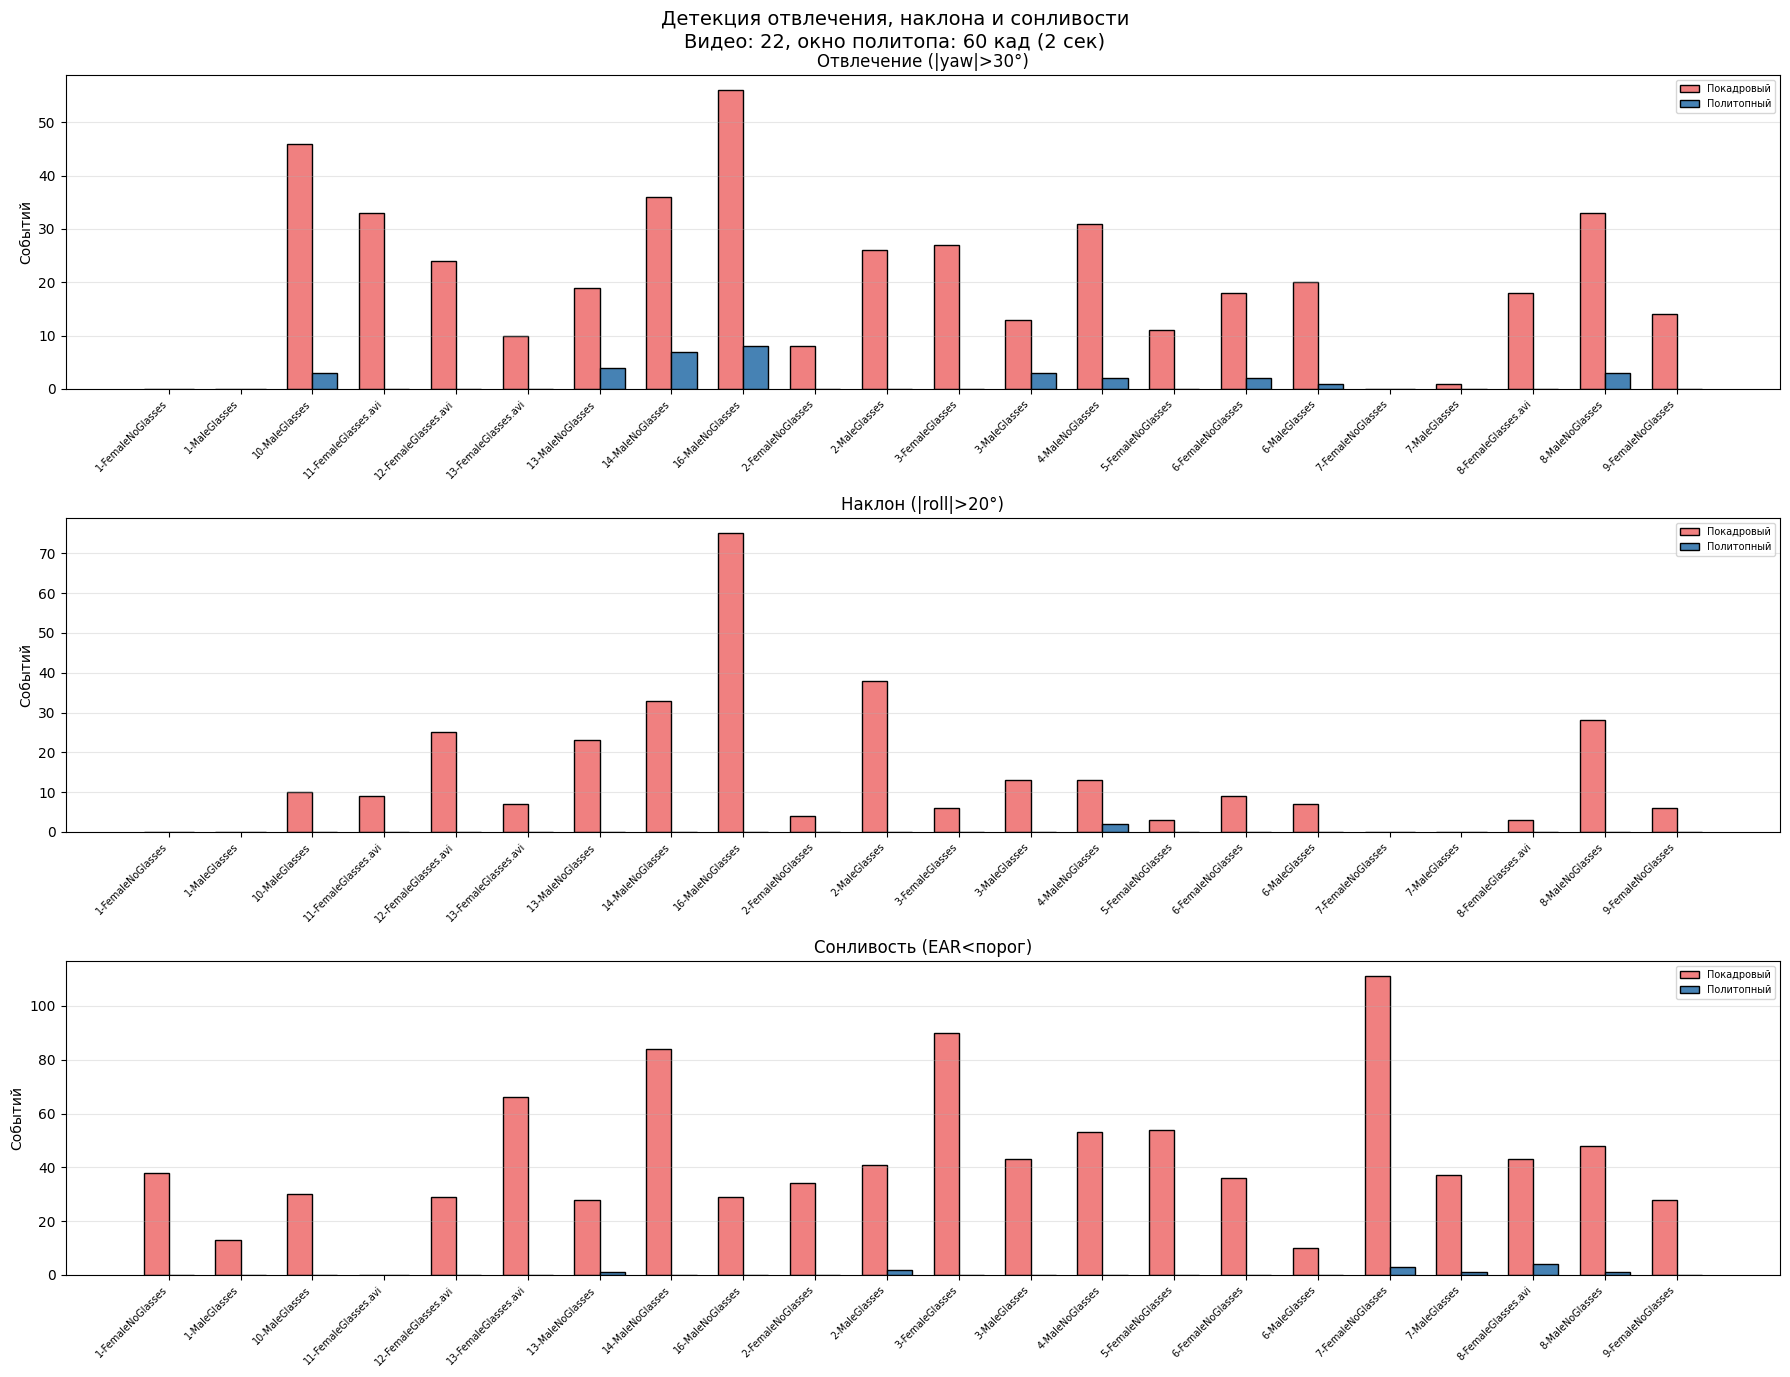

График сохранен: batch_distraction_drowsiness\plots\batch_summary.png

ЭТАП 3: ОТЧЕТ
ОТЧЕТ: ОТВЛЕЧЕНИЕ, НАКЛОН, СОНЛИВОСТЬ
Дата: 2026-05-05 22:43:21
Видео: 22
Окно политопа: 60 кад (2 сек)

Отвлечение (|yaw|>30°):
  Покадровых событий: 444
  Политопных событий: 33
  Общее снижение: 92.6%
  Среднее снижение: 81.1%

Наклон (|roll|>20°):
  Покадровых событий: 312
  Политопных событий: 2
  Общее снижение: 99.4%
  Среднее снижение: 81.1%

Сонливость (EAR<порог):
  Покадровых событий: 945
  Политопных событий: 12
  Общее снижение: 98.7%
  Среднее снижение: 94.3%

Результаты по видео:
----------------------------------------
  1-FemaleNoGlasses:
    Отвлечение: покадр 0, политоп 0, сниж 0%
    Наклон: покадр 0, политоп 0, сниж 0%
    Сонливость: покадр 38, политоп 0, сниж 100%
  1-MaleGlasses:
    Отвлечение: покадр 0, политоп 0, сниж 0%
    Наклон: покадр 0, политоп 0, сниж 0%
    Сонливость: покадр 13, политоп 0, сниж 100%
  10-MaleGlasses:
    Отвлечение: покадр 46, политоп 3, сниж 93%
   

In [17]:
def main():
    """Главная функция."""
    print("=" * 70)
    print("ПАКЕТНЫЙ АНАЛИЗ: ОТВЛЕЧЕНИЕ, НАКЛОН, СОНЛИВОСТЬ")
    print("=" * 70)

    extractor = FaceMetricsExtractor()
    analyzer = SingleVideoAnalyzer(config, extractor)
    comparator = BatchComparator(config, analyzer)
    visualizer = BatchVisualizer(config)
    reporter = ReportGenerator(config)

    print("\nЭТАП 1: АНАЛИЗ ВИДЕО")
    df_results = comparator.run()

    if df_results is None:
        print("Нет результатов.")
        return None

    print("\nЭТАП 2: ВИЗУАЛИЗАЦИЯ")
    visualizer.plot_summary(df_results)

    print("\nЭТАП 3: ОТЧЕТ")
    reporter.generate(df_results)

    print("\nГОТОВО.")
    return df_results


if __name__ == "__main__":
    results = main()

# Детекция отвлечения, наклона и сонливости (пакетный анализ)

## Методология

**Выборка:** 22 видео из датасета YawDD (после исключения 7 видео с недостаточным количеством нейтральных кадров по критерию MAR).

**Три независимые системы детекции:**

| Система | Признак | Условие | Окно политопа | Обоснование |
|:---|:---|:---|:---|:---|
| Отвлечение внимания | \|yaw\| (поворот влево-вправо) | \|yaw\| > 30° | 60 кадров (2 сек) | Требуется подтверждение устойчивости |
| Наклон головы | \|roll\| (наклон к плечу) | \|roll\| > 20° | 60 кадров (2 сек) | Требуется подтверждение устойчивости |
| Сонливость | EAR (открытость глаз) | EAR < порог | 60 кадров (2 сек) | Требуется подтверждение устойчивости |

**Пороги:**
- Yaw: фиксированный порог 30°, обоснован литературой по DMS (водитель смотрит в зеркало/на пассажира)
- Roll: фиксированный порог 20°, эмпирический порог для детекции потери сознания/засыпания
- EAR: адаптивный порог = EAR_базовый × 0.6 (Soukupová & Čech, 2016). EAR_базовый — медиана кадров с открытыми глазами

**Важно:** пороги yaw и roll являются абсолютными угловыми величинами и **не требуют калибровки**, так как не зависят от индивидуальной анатомии водителя. Калибровка может потребоваться только для учета нестандартной установки камеры (baseline-коррекция нейтрального положения), что не применялось в данном эксперименте.

**Метрика:** сравнение покадрового и политопного подходов на уровне событий.

## Результаты

### Сводная статистика

| Система | Покадровых событий | Политопных событий | Общее снижение | Среднее снижение |
|:---|:---|:---|:---|:---|
| Отвлечение (\|yaw\| > 30°) | 444 | 33 | 92.6% | 81.1% |
| Наклон (\|roll\| > 20°) | 312 | 2 | 99.4% | 81.1% |
| Сонливость (EAR < порог) | 945 | 12 | 98.7% | 94.3% |

### Анализ по видео

**Отвлечение внимания:** На 16 из 22 видео достигнуто 100% снижение ложных событий. Покадровый метод зафиксировал 444 события (кратковременные повороты головы), из которых политоп подтвердил только 33 как длительные (>2 сек). На видео `13-MaleNoGlasses` и `14-MaleNoGlasses` обнаружены реальные отвлечения (4 и 7 событий соответственно).

**Наклон головы:** На 19 из 22 видео достигнуто 100% снижение. Из 312 покадровых событий политоп подтвердил только 2 (на видео `4-MaleNoGlasses`). Это свидетельствует о том, что кратковременные наклоны головы являются нормой при вождении, и только длительные наклоны (>2 сек) представляют опасность.

**Сонливость:** На 17 из 22 видео достигнуто 100% снижение. Из 945 покадровых событий (включая моргания и закрытие глаз при зевке) политоп подтвердил только 12 как длительное закрытие глаз (>2 сек). Наибольшее количество подтвержденных событий — на видео `8-FemaleGlasses.avi` (4 события).

### Интерпретация

**1. Высокий процент снижения обусловлен природой датасета.**

Датасет YawDD содержит видеозаписи водителей в нормальном состоянии (без выраженного отвлечения, наклонов или сонливости). Большинство покадровых срабатываний — это естественные движения головы и моргания, которые не представляют опасности. Политопный подход успешно фильтрует эти кратковременные события.

**2. Политоп подтверждает только устойчивые события.**

Подтверждено 33 события отвлечения  — это моменты, когда водитель удерживал голову повернутой более 2 секунд (например, смотрел в зеркало). Подтверждено 2 события наклона головы — длительные наклоны головы. Оба случая присутствуют на видео (`4-MaleNoGlasses`).

**3. Сонливость детектируется эффективно.**

Из 945 покадровых событий (моргания, закрытие глаз при зевке) только 12 подтверждены как длительное закрытие глаз. Это в 79 раз меньше, чем при покадровом подходе, что демонстрирует эффективность политопной фильтрации морганий.

**4. Отсутствие событий на части видео — ожидаемый результат.**

На видео `1-FemaleNoGlasses`, `7-FemaleNoGlasses` и др. нет ни одного политопного события отвлечения или наклона. Это означает, что водитель на этих видео не отвлекался и не наклонял голову на длительное время — нормальная ситуация для безопасного вождения.

## Научные выводы

1. **Политопный подход эффективен для фильтрации кратковременных событий.** Снижение ложных срабатываний составило 92.6-99.4% (общее) и 81.1-94.3% (среднее по видео), учитывая природу датасета.

2. **Фиксированные пороги yaw (30°) и roll (20°) не требуют калибровки**, так как являются абсолютными угловыми величинами, не зависящими от индивидуальной анатомии водителя.

3. **Адаптивный порог EAR (базовый × 0.6) корректно учитывает индивидуальные особенности** глаз водителя, что особенно важно для детекции сонливости.

4. **Окно 2 секунды является обоснованным компромиссом** между чувствительностью (реакция на опасное событие) и специфичностью (фильтрация естественных движений).

5. **Системы готовы к интеграции в модуль Дмитрия.** Все три детектора работают на едином источнике признаков (MediaPipe Face Mesh) и могут выполняться параллельно с детекцией зевка в реальном времени.